In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [59]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


In [61]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [62]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [63]:
df.mean(numeric_only=True)

age                         15.928333
daily_social_media_hours     4.536667
sleep_hours                  6.449417
screen_time_before_sleep     1.740333
academic_performance         2.990383
physical_activity            1.014500
stress_level                 5.445833
anxiety_level                5.636667
addiction_level              5.565000
depression_label             0.025833
dtype: float64

In [64]:
df.groupby("gender").mean(numeric_only=True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
gender,,,,,,,,,,
female,15.905983,4.512991,6.496410,1.760000,3.000547,1.004274,5.422222,5.687179,5.48547,0.029060
male,15.949593,4.559187,6.404715,1.721626,2.980715,1.024228,5.468293,5.588618,5.64065,0.022764


In [65]:
df["platform_usage"].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

In [66]:
df[["daily_social_media_hours","sleep_hours"]].corr()

,daily_social_media_hours,sleep_hours
daily_social_media_hours,1.000000,-0.009472
sleep_hours,-0.009472,1.000000


In [67]:
df[["daily_social_media_hours","academic_performance"]].corr()

,daily_social_media_hours,academic_performance
daily_social_media_hours,1.000000,0.013179
academic_performance,0.013179,1.000000


In [68]:
df[["stress_level","anxiety_level","addiction_level"]].describe()

,stress_level,anxiety_level,addiction_level
count,1200.000000,1200.000000,1200.000000
mean,5.445833,5.636667,5.565000
std,2.903290,2.859453,2.830627
min,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000
50%,5.000000,6.000000,6.000000
75%,8.000000,8.000000,8.000000
max,10.000000,10.000000,10.000000


In [69]:
df.groupby("depression_label").mean(numeric_only=True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
depression_label,,,,,,,,,
0,15.924722,4.478785,6.494183,1.742258,2.990248,1.016168,5.365269,5.557742,5.571429
1,16.064516,6.719355,4.761290,1.667742,2.995484,0.951613,8.483871,8.612903,5.322581


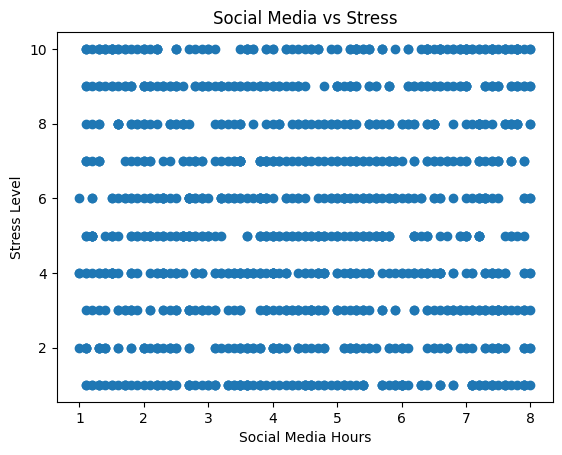

In [70]:
plt.figure()
plt.scatter(df["daily_social_media_hours"], df["stress_level"])
plt.xlabel("Social Media Hours")
plt.ylabel("Stress Level")
plt.title("Social Media vs Stress")
plt.show()

<Figure size 640x480 with 0 Axes>

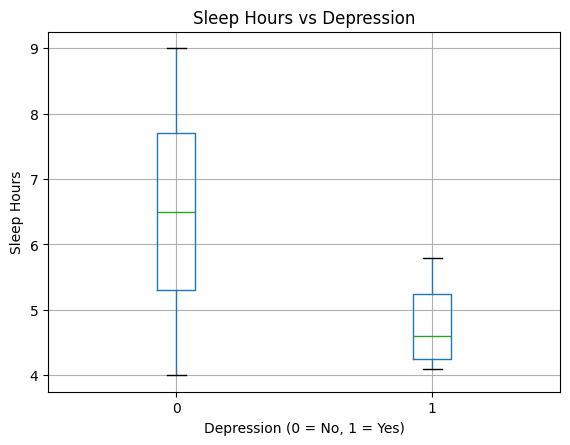

In [71]:
plt.figure()
df.boxplot(column="sleep_hours", by="depression_label")
plt.title("Sleep Hours vs Depression")
plt.suptitle("")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Sleep Hours")
plt.show()

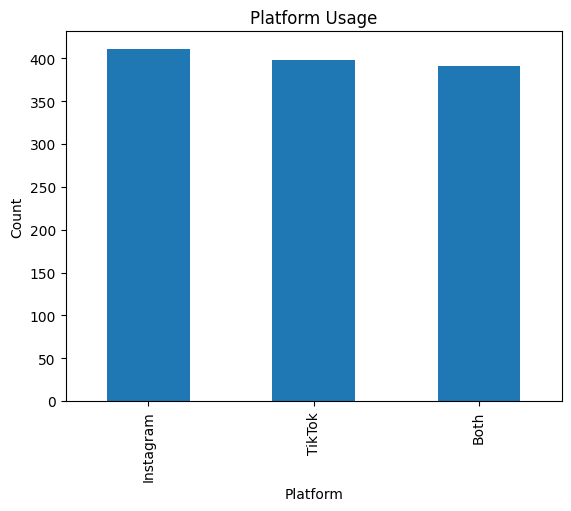

In [72]:
plt.figure()
df["platform_usage"].value_counts().plot(kind="bar")
plt.title("Platform Usage")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.show()

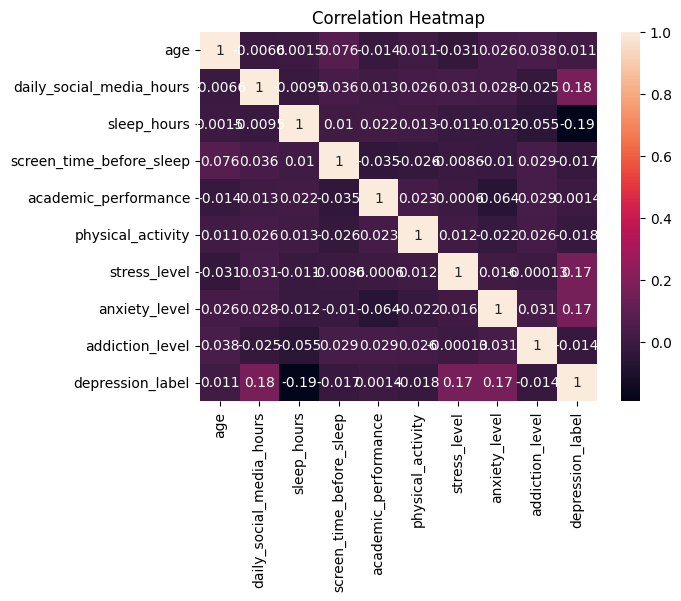

In [73]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [75]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["platform_usage"] = le.fit_transform(df["platform_usage"])
df["academic_performance"] = le.fit_transform(df["academic_performance"])
df["physical_activity"] = le.fit_transform(df["physical_activity"])
df["social_interaction_level"] = le.fit_transform(df["social_interaction_level"])


In [76]:
#Features & Target
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

In [77]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
#Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

#prediction
y_pred = model.predict(X_test)

In [79]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9833333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.33      0.50         6

    accuracy                           0.98       240
   macro avg       0.99      0.67      0.75       240
weighted avg       0.98      0.98      0.98       240



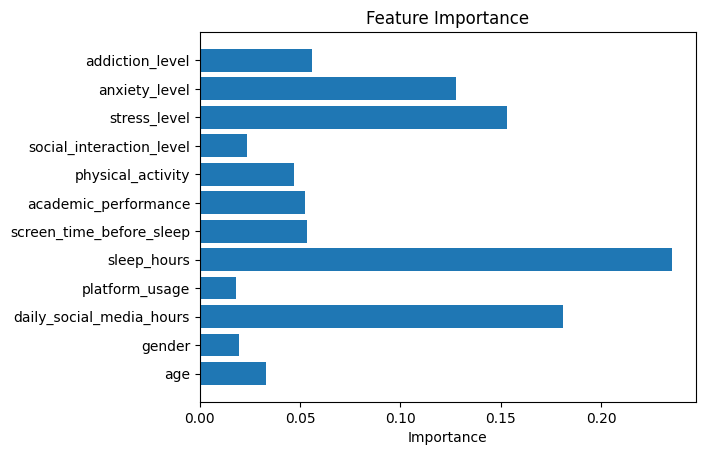

In [80]:
importance = model.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

<Axes: ylabel='daily_social_media_hours'>

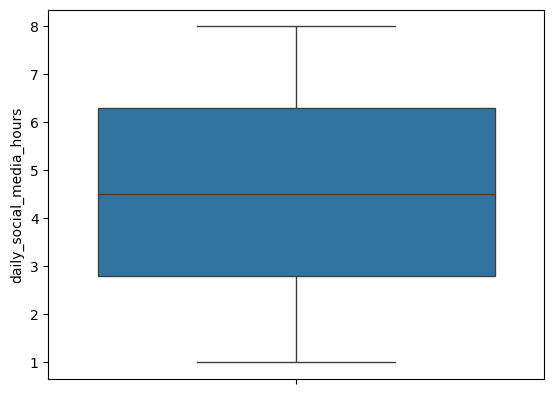

In [83]:
sns.boxplot(df["daily_social_media_hours"])

Summary

This project analyzes the impact of social media usage on students mental health using data analysis and machine learning techniques. The dataset includes various features such as age, gender, daily social media usage, sleep hours, academic performance, stress level, anxiety level, addiction level, and depression status. Initially, data cleaning was performed to check for missing values and understand the dataset. Then, exploratory data analysis (EDA) was conducted to identify patterns and relationships between variables. The analysis revealed that higher social media usage is associated with increased stress and anxiety, while lower sleep hours are linked to a higher risk of depression. Various visualizations such as scatter plots, box plots, bar charts, and heatmaps were used to better understand these relationships. Finally, machine learning models like Random Forest and Logistic Regression were applied to predict depression, and their performance was evaluated. The project concludes that excessive social media usage can negatively affect students' mental health, and maintaining a balanced lifestyle with proper sleep can help improve overall well-being.